In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

C:\Users\LJENG\AppData\Roaming\Python\Python38\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
df=pd.read_csv("social_media_engagement.csv")
df

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive
...,...,...,...,...,...,...,...,...,...
95,96,Instagram,carousel,7/12/2023 17:45,36,294,911,Wednesday,positive
96,97,Twitter,video,10/27/2023 23:45,314,108,458,Friday,neutral
97,98,Twitter,text,8/5/2023 8:45,229,179,38,Saturday,positive
98,99,Instagram,poll,12/29/2023 12:15,5000,500,204,Friday,positive


In [4]:
def rating(x):
    if x>3000:
        return "Good"
    else:
        return "Bad"

In [7]:
df["Ratings"]=df["likes"].apply(rating)
df

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score,Ratings
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive,Bad
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral,Good
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative,Good
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative,Bad
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive,Good
...,...,...,...,...,...,...,...,...,...,...
95,96,Instagram,carousel,7/12/2023 17:45,36,294,911,Wednesday,positive,Bad
96,97,Twitter,video,10/27/2023 23:45,314,108,458,Friday,neutral,Bad
97,98,Twitter,text,8/5/2023 8:45,229,179,38,Saturday,positive,Bad
98,99,Instagram,poll,12/29/2023 12:15,5000,500,204,Friday,positive,Good


In [6]:
def risk(x):
    if x["likes"]>500 and x["comments"]<100:
        return "High"
    elif x["likes"]>2000:
        return "Medium"
    elif x["shares"]>1000:
        return "Low"

In [9]:
df["Risk"]=df.apply(risk,axis=1)
df

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score,Ratings,Risk
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive,Bad,Medium
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral,Good,Medium
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative,Good,Medium
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative,Bad,High
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive,Good,Medium
...,...,...,...,...,...,...,...,...,...,...,...
95,96,Instagram,carousel,7/12/2023 17:45,36,294,911,Wednesday,positive,Bad,None
96,97,Twitter,video,10/27/2023 23:45,314,108,458,Friday,neutral,Bad,None
97,98,Twitter,text,8/5/2023 8:45,229,179,38,Saturday,positive,Bad,None
98,99,Instagram,poll,12/29/2023 12:15,5000,500,204,Friday,positive,Good,Medium


In [ ]:
# df.apply(more,args=(5,),v=10)

In [13]:
df.groupby("platform")

In [14]:
df.groupby("platform").head()
# 5 entries of each category. here 5 entries of instagram, 5 of facebook and 5 of twitter

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score,Ratings,Risk
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive,Bad,Medium
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral,Good,Medium
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative,Good,Medium
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative,Bad,High
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive,Good,Medium
5,6,Instagram,carousel,5/5/2023 20:00,256,186,211,Friday,neutral,Bad,None
6,7,Instagram,image,2/26/2023 11:45,1982,30,906,Sunday,positive,Bad,High
7,8,Instagram,text,10/28/2023 19:30,1274,45,216,Saturday,neutral,Bad,High
8,9,Facebook,video,5/2/2023 6:15,317,249,221,Tuesday,neutral,Bad,None
9,10,Twitter,carousel,5/11/2023 11:00,1878,225,438,Thursday,neutral,Bad,None


In [15]:
df.platform.unique()

array(['Facebook', 'Instagram', 'Twitter'], dtype=object)

In [18]:
for name,data in df.groupby("platform"):
    print(name,"\n",data)

Facebook 
     post_id  platform post_type         post_time  likes  comments  shares  \
0         1  Facebook     image   8/17/2023 14:45   2121       474     628   
1         2  Facebook  carousel    5/14/2023 0:45   3660       432     694   
8         9  Facebook     video     5/2/2023 6:15    317       249     221   
12       13  Facebook  carousel  11/11/2023 15:45     45        78     375   
14       15  Facebook  carousel    1/9/2023 20:00    889       314     262   
19       20  Facebook     image    2/2/2023 16:00    455        86      79   
25       26  Facebook  carousel    10/5/2023 6:30   1992        70     515   
27       28  Facebook      poll     3/1/2023 8:00   2083       500     388   
28       29  Facebook     image    1/7/2023 10:30    548       153     731   
29       30  Facebook  carousel     2/3/2023 0:30   4594       216     739   
30       31  Facebook      poll   9/10/2023 13:45   4795       449     978   
35       36  Facebook     video    4/8/2023 19:15   5

In [20]:
df.groupby("platform").sample

<bound method GroupBy.sample of <pandas.core.groupby.generic.DataFrameGroupBy object at 0x000001C112DD81F0>>

In [21]:
df.groupby("platform").describe

<bound method GroupBy.describe of <pandas.core.groupby.generic.DataFrameGroupBy object at 0x000001C112DD8D00>>

In [22]:
df.groupby("platform").groups

{'Facebook': [0, 1, 8, 12, 14, 19, 25, 27, 28, 29, 30, 35, 36, 38, 46, 47, 57, 61, 65, 66, 69, 71, 72, 74, 79, 80, 83, 84, 87, 90, 91, 93], 'Instagram': [2, 5, 6, 7, 16, 23, 26, 31, 34, 39, 41, 43, 45, 49, 53, 55, 56, 59, 60, 63, 64, 67, 70, 73, 75, 77, 78, 81, 82, 86, 89, 92, 94, 95, 98, 99], 'Twitter': [3, 4, 9, 10, 11, 13, 15, 17, 18, 20, 21, 22, 24, 32, 33, 37, 40, 42, 44, 48, 50, 51, 52, 54, 58, 62, 68, 76, 85, 88, 96, 97]}

In [25]:
df.groupby("platform").nunique()
# difference btw unique and nunique?

,post_id,post_type,post_time,likes,comments,shares,post_day,sentiment_score,Ratings,Risk
platform,,,,,,,,,,
Facebook,32,5,32,29,28,32,7,3,2,2
Instagram,36,5,36,33,34,36,7,3,2,2
Twitter,32,5,32,32,31,31,7,3,2,2


In [27]:
df.groupby("platform")["likes"].sum()

platform
Facebook      86392
Instagram    107994
Twitter       43795
Name: likes, dtype: int64

In [28]:
df.groupby("platform",as_index=False)["likes"].sum()

,platform,likes
0,Facebook,86392
1,Instagram,107994
2,Twitter,43795


In [31]:
df.groupby("platform")[["likes","comments","shares"]].mean()

,likes,comments,shares
platform,,,
Facebook,2699.750000,248.906250,474.375000
Instagram,2999.833333,232.444444,525.166667
Twitter,1368.593750,122.906250,233.718750


In [34]:
df.groupby("platform",as_index=False).agg({"likes":[sum,"mean"],"comments":"mean"})

platform   likes                 comments
                 sum         mean        mean
0   Facebook   86392  2699.750000  248.906250
1  Instagram  107994  2999.833333  232.444444
2    Twitter   43795  1368.593750  122.906250

In [35]:
df.groupby("platform").nth(0)

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score,Ratings,Risk
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive,Bad,Medium
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative,Good,Medium
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative,Bad,High


In [37]:
dff=pd.read_csv("movies.csv")
dff

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1624,Tera Mera Saath Rahen,tt0301250,https://upload.wikimedia.org/wikipedia/en/2/2b...,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...,Tera Mera Saath Rahen,Tera Mera Saath Rahen,0,2001,148,Drama,4.9,278,Raj Dixit lives with his younger brother Rahu...,A man is torn between his handicapped brother ...,NaN,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,NaN,7 November 2001 (India)
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
1626,Sabse Bada Sukh,tt0069204,NaN,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh,Sabse Bada Sukh,Sabse Bada Sukh,0,2018,\N,Comedy|Drama,6.1,13,Village born Lalloo re-locates to Bombay and ...,Village born Lalloo re-locates to Bombay and ...,NaN,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,NaN,NaN
1627,Daaka,tt10833860,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Daaka,Daaka,Daaka,0,2019,136,Action,7.4,38,Shinda tries robbing a bank so he can be wealt...,Shinda tries robbing a bank so he can be wealt...,NaN,Gippy Grewal|Zareen Khan|,NaN,1 November 2019 (USA)


In [43]:
dff.groupby("genres")["imdb_rating"].mean()

genres
Action                        5.086667
Action|Adventure              4.433333
Action|Adventure|Animation    5.766667
Action|Adventure|Comedy       4.709091
Action|Adventure|Crime        3.500000
                                ...   
Romance|Thriller              4.225000
Sci-Fi                        5.800000
Sport                         5.300000
Thriller                      4.986957
War                           4.100000
Name: imdb_rating, Length: 205, dtype: float64

In [46]:
dff.groupby("genres")["imdb_rating"].mean().max()

8.6

In [50]:
dff.groupby("genres")["imdb_rating"].mean().sort_values(ascending=False).head(3)

genres
Documentary|Sport       8.6
Documentary|War         8.3
Drama|Fantasy|Horror    8.2
Name: imdb_rating, dtype: float64

In [55]:
dff.groupby("genres")[["imdb_rating","title_y"]].max()

,imdb_rating,title_y
genres,,
Action,7.4,Vidhyaarthi: The Power of Students
Action|Adventure,5.3,Zokkomon
Action|Adventure|Animation,6.8,Toonpur Ka Superrhero
Action|Adventure|Comedy,7.2,Total Dhamaal
Action|Adventure|Crime,3.5,Jai Veeru: Friends Forever
...,...,...
Romance|Thriller,5.7,Valentine's Night
Sci-Fi,5.8,Aalaap
Sport,5.3,22 Yards


In [59]:
dff.groupby("genres")["imdb_votes"].max().sort_values(ascending=False).head(1)

genres
Comedy|Drama    310481
Name: imdb_votes, dtype: int64

In [60]:
df=pd.read_csv("social_media_engagement.csv")

In [61]:
df.corr(numeric_only=True)
# correlation

,post_id,likes,comments,shares
post_id,1.000000,0.139260,0.135507,0.071436
likes,0.139260,1.000000,0.295240,0.244302
comments,0.135507,0.295240,1.000000,0.254583
shares,0.071436,0.244302,0.254583,1.000000


<Axes: >

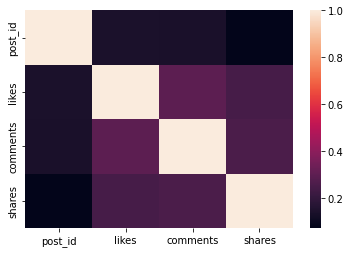

In [62]:
sns.heatmap(df.corr(numeric_only=True))

<Axes: >

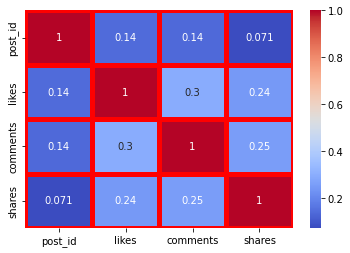

In [67]:
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm",linewidths=5,linecolor="red",annot=True)

<Axes: >

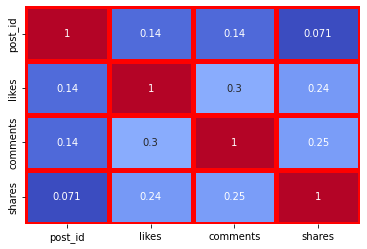

In [68]:
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm",linewidths=5,linecolor="red",annot=True,cbar=False)

<Axes: >

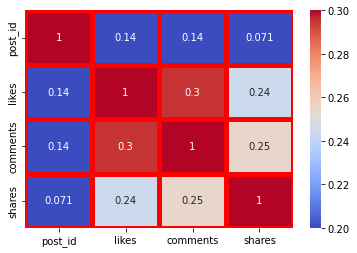

In [71]:
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm",linewidths=5,linecolor="red",annot=True,vmin=0.2,vmax=0.3)

<Axes: xlabel='likes'>

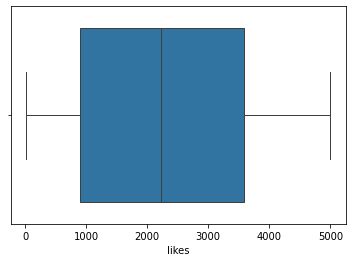

In [76]:
sns.boxplot(data=df,x="likes")

<Axes: xlabel='likes'>

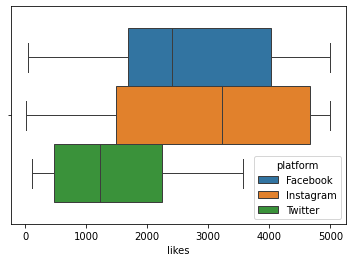

In [75]:
sns.boxplot(data=df,x="likes",hue="platform")

<Axes: xlabel='likes', ylabel='comments'>

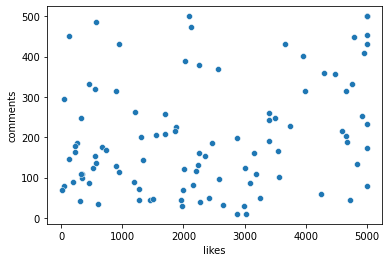

In [79]:
sns.scatterplot(data=df,x="likes",y="comments")

<Axes: xlabel='likes', ylabel='comments'>

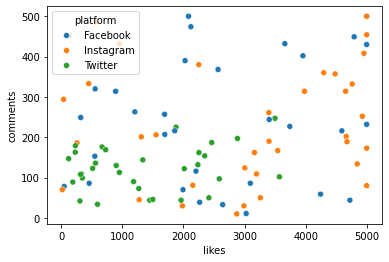

In [78]:
sns.scatterplot(data=df,x="likes",y="comments",hue="platform")

<Axes: xlabel='likes', ylabel='comments'>

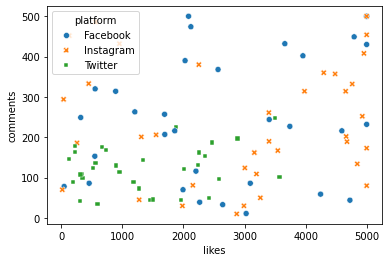

In [80]:
sns.scatterplot(data=df,x="likes",y="comments",hue="platform",style="platform")

<Axes: xlabel='likes', ylabel='comments'>

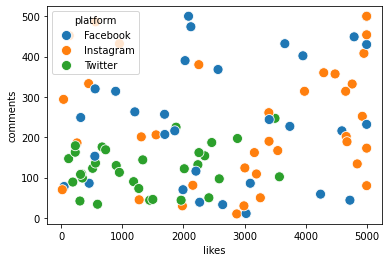

In [81]:
sns.scatterplot(data=df,x="likes",y="comments",hue="platform",s=100)

In [82]:
import plotly

ModuleNotFoundError: No module named 'plotly'